In [ ]:
!pip uninstall -y numpy

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [ ]:
!pip install numpy==1.25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 24.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.25.0 which is incompatible.
blosc2 3.3.2 requires numpy>=1.26, but you have numpy 1.25.0 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.25.0 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.25.0 which is incompatible.


In [ ]:
# Install libraries (run once per session)
!pip install --quiet nltk gensim
!pip install --quiet numpy scipy scikit-learn
# Download NLTK data
import nltk
nltk.download('punkt_tab')          # Pre-trained tokenizers for splitting text into words and sentences.
nltk.download('stopwords')     #  collection of common stopwords in many languages (like “the”, “and”, “is”)
nltk.download('wordnet')       # Used for lemmatization — converting words to their base form (e.g., "running" → "run").
nltk.download('averaged_perceptron_tagger')  # Tags words as nouns, verbs, adjectives, etc., which helps in better lemmatization and grammar analysis.
nltk.download('tagsets')    # Detailed descriptions of POS tag symbols (e.g., “NN” = Noun, “VB” = Verb).
# Download the specific resource if needed
nltk.download('averaged_perceptron_tagger_eng')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 13.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Unzipping help/tagsets.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
import re
import unicodedata
import nltk
from google.colab import files
import pickle
import pandas as pd
from nltk.tokenize    import word_tokenize, sent_tokenize
from nltk.corpus      import stopwords, wordnet
from nltk.stem        import PorterStemmer, WordNetLemmatizer
from nltk             import pos_tag
from nltk.data        import load

# ── 1) Upload & load your pickle ─────────────────────────────────────────
uploaded = files.upload()
fn = list(uploaded.keys())[0]
with open(fn, 'rb') as f:
    obj = pickle.load(f)
if isinstance(obj, pd.DataFrame):
    df = obj
elif isinstance(obj, dict):
    df = pd.DataFrame.from_dict(obj)
elif isinstance(obj, list):
    df = pd.DataFrame(obj)
else:
    df = pd.DataFrame({'value': [obj]})

# ── 2) Download only the correct NLTK resources ───────────────────────────
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('tagsets')

# ── 3) Define cleaning & preprocessing (unchanged) ────────────────────────
def clean_text(text: str) -> str:
    text = unicodedata.normalize('NFKC', str(text)).lower()
    text = re.sub(r'\$.*?\$', ' xmathx ', text)
    text = text.replace('\n',' ')
    text = re.sub(r'\d+',' xnumx ', text)
    text = re.sub(r'[\+\-\*\/\^\=\%]+',' xnumx ', text)
    text = re.sub(r'\.{2,}',' ', text)
    text = re.sub(r'(?<=\w)-(?=\w)',' ', text)
    text = re.sub(r'[^\w\s]',' ', text)
    return re.sub(r'\s+',' ', text).strip()

ps         = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    sents    = sent_tokenize(text)
    words    = word_tokenize(text)
    filtered = [w for w in words if w.isalnum() and w.lower() not in stop_words]
    stems    = [ps.stem(w)               for w in filtered]
    lemmas   = [lemmatizer.lemmatize(w) for w in filtered]
    tags     = pos_tag(filtered)
    return pd.Series({
        'sentences':         sents,
        'tokens':            words,
        'filtered_tokens':   filtered,
        'stemmed_tokens':    stems,
        'lemmatized_tokens': lemmas,
        'pos_tags':          tags
    })

# ── 4) Clean raw text and then apply NLP preprocess ───────────────────────
text_col = 0
df[text_col] = df[text_col].astype(str).apply(clean_text)

# instead of df = df.join(...), do:
nlp_df = df[text_col].apply(preprocess)
for col in nlp_df.columns:
    df[col] = nlp_df[col]

# ── 5) Verify ─────────────────────────────────────────────────────────────
print("Final df columns:", df.columns.tolist())
print(df[[text_col, 'filtered_tokens']].head())




Saving train_data_text (1).pkl to train_data_text (1).pkl


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!


Final df columns: [0, 'sentences', 'tokens', 'filtered_tokens', 'stemmed_tokens', 'lemmatized_tokens', 'pos_tags']
                                                   0  \
0  in article xnumx xnumx grv xnumx psuvm psu edu...   
1  in article xnumx apr xnumx xnumx xnumx rchland...   
2  you can get a xnumx little xnumx uv by putting...   
3  nntp xnumx posting xnumx host access digex net...   
4  i understand that the new gps boxes now have a...   

                                     filtered_tokens  
0  [article, xnumx, xnumx, grv, xnumx, psuvm, psu...  
1  [article, xnumx, apr, xnumx, xnumx, xnumx, rch...  
2  [get, xnumx, little, xnumx, uv, putting, heavy...  
3  [nntp, xnumx, posting, xnumx, host, access, di...  
4  [understand, new, gps, boxes, option, known, d...  


In [ ]:
import re
import unicodedata
import nltk
from google.colab import files
import pickle
import pandas as pd
from nltk.tokenize    import word_tokenize, sent_tokenize
from nltk.corpus      import stopwords, wordnet
from nltk.stem        import PorterStemmer, WordNetLemmatizer
from nltk             import pos_tag
from nltk.data        import load

# ── 1) Upload & load your pickle ─────────────────────────────────────────
uploaded = files.upload()
fn = list(uploaded.keys())[0]
with open(fn, 'rb') as f:
    obj = pickle.load(f)

if isinstance(obj, pd.DataFrame):
    df = obj
elif isinstance(obj, dict):
    df = pd.DataFrame.from_dict(obj)
elif isinstance(obj, list):
    df = pd.DataFrame(obj)
else:
    df = pd.DataFrame({'value': [obj]})

# ── Print top 20 rows row-wise ────────────────────────────────────────────
print("Top 20 rows of loaded DataFrame:")
for idx, row in df.head(20).iterrows():
    print(f"Row {idx}: {row.to_dict()}")

# ── 2) Download only the correct NLTK resources ───────────────────────────
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('tagsets')

# ── 3) Define cleaning & preprocessing (unchanged) ────────────────────────
def clean_text(text: str) -> str:
    text = unicodedata.normalize('NFKC', str(text)).lower()
    text = re.sub(r'\$.*?\$', ' xmathx ', text)
    text = text.replace('\n',' ')
    text = re.sub(r'\d+',' xnumx ', text)
    text = re.sub(r'[\+\-\*\/\^\=\%]+',' xnumx ', text)
    text = re.sub(r'\.{2,}',' ', text)
    text = re.sub(r'(?<=\w)-(?=\w)',' ', text)
    text = re.sub(r'[^\w\s]',' ', text)
    return re.sub(r'\s+',' ', text).strip()

ps         = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    sents    = sent_tokenize(text)
    words    = word_tokenize(text)
    filtered = [w for w in words if w.isalnum() and w.lower() not in stop_words]
    stems    = [ps.stem(w)               for w in filtered]
    lemmas   = [lemmatizer.lemmatize(w) for w in filtered]
    tags     = pos_tag(filtered)
    return pd.Series({
        'sentences':         sents,
        'tokens':            words,
        'filtered_tokens':   filtered,
        'stemmed_tokens':    stems,
        'lemmatized_tokens': lemmas,
        'pos_tags':          tags
    })

# ── 4) Clean raw text and then apply NLP preprocess ───────────────────────
text_col = 0
df[text_col] = df[text_col].astype(str).apply(clean_text)

nlp_df = df[text_col].apply(preprocess)
for col in nlp_df.columns:
    df[col] = nlp_df[col]

# ── 5) Verify ─────────────────────────────────────────────────────────────
print("Final df columns:", df.columns.tolist())
print(df[[text_col, 'filtered_tokens']].head())



Saving train_data_text (1).pkl to train_data_text (1) (1).pkl
Top 20 rows of loaded DataFrame:
Row 0: {0: "\nIn article <93089.204431GRV101@psuvm.psu.edu> Callec Dradja <GRV101@psuvm.psu.edu> writes:\n>I am a bit nervous about posting this beacause it is begining to\n>stray fron the topic of space but then again that doesn't seem to\n>stop alot of other people. :-)\n>\n>With all of this talk about breathing at high pressures, I began\n>to think about the movie Abyss. If you remember, in that movie one\n>of the characters dove to great depths by wearing a suit that used\n>a fluid that carries oxegen as opposed to some sort of gas. Now I\n>have heard that mice can breath this fluid but for some reason, humans\n>are unable to. Does anyone know more details about this?\n>\n>Gregson Vaux\n>\n\nI believe the reason is that the lung diaphram gets too tired to pump\nthe liquid in and out and simply stops breathing after 2-3 minutes.\nSo if your in the vehicle ready to go they better not put yo

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!


Final df columns: [0, 'sentences', 'tokens', 'filtered_tokens', 'stemmed_tokens', 'lemmatized_tokens', 'pos_tags']
                                                   0  \
0  in article xnumx xnumx grv xnumx psuvm psu edu...   
1  in article xnumx apr xnumx xnumx xnumx rchland...   
2  you can get a xnumx little xnumx uv by putting...   
3  nntp xnumx posting xnumx host access digex net...   
4  i understand that the new gps boxes now have a...   

                                     filtered_tokens  
0  [article, xnumx, xnumx, grv, xnumx, psuvm, psu...  
1  [article, xnumx, apr, xnumx, xnumx, xnumx, rch...  
2  [get, xnumx, little, xnumx, uv, putting, heavy...  
3  [nntp, xnumx, posting, xnumx, host, access, di...  
4  [understand, new, gps, boxes, option, known, d...  


In [ ]:
# Simply print the entire DataFrame to stdout
print(df)

# If you’d rather preview, print just the first 10 rows:
print(df.head(10))

# In a Jupyter/Colab notebook you can also use:
from IPython.display import display
display(df)


                                                      0  \
0     in article xnumx xnumx grv xnumx psuvm psu edu...   
1     in article xnumx apr xnumx xnumx xnumx rchland...   
2     you can get a xnumx little xnumx uv by putting...   
3     nntp xnumx posting xnumx host access digex net...   
4     i understand that the new gps boxes now have a...   
...                                                 ...   
1495  nntp xnumx posting xnumx host wcsub ctstateu e...   
1496  in c xnumx tvl xnumx xnumx in hermes hrz uni x...   
1497  in article xnumx cup portal com thyagi cup por...   
1498  xnumx miles black leather tank bra tank bag co...   
1499  nntp xnumx posting xnumx host grissom larc nas...   

                                              sentences  \
0     [in article xnumx xnumx grv xnumx psuvm psu ed...   
1     [in article xnumx apr xnumx xnumx xnumx rchlan...   
2     [you can get a xnumx little xnumx uv by puttin...   
3     [nntp xnumx posting xnumx host access digex ne...

,0,sentences,tokens,filtered_tokens,stemmed_tokens,lemmatized_tokens,pos_tags
0,in article xnumx xnumx grv xnumx psuvm psu edu...,[in article xnumx xnumx grv xnumx psuvm psu ed...,"[in, article, xnumx, xnumx, grv, xnumx, psuvm,...","[article, xnumx, xnumx, grv, xnumx, psuvm, psu...","[articl, xnumx, xnumx, grv, xnumx, psuvm, psu,...","[article, xnumx, xnumx, grv, xnumx, psuvm, psu...","[(article, NN), (xnumx, NNP), (xnumx, NNP), (g..."
1,in article xnumx apr xnumx xnumx xnumx rchland...,[in article xnumx apr xnumx xnumx xnumx rchlan...,"[in, article, xnumx, apr, xnumx, xnumx, xnumx,...","[article, xnumx, apr, xnumx, xnumx, xnumx, rch...","[articl, xnumx, apr, xnumx, xnumx, xnumx, rchl...","[article, xnumx, apr, xnumx, xnumx, xnumx, rch...","[(article, NN), (xnumx, NNP), (apr, NN), (xnum..."
2,you can get a xnumx little xnumx uv by putting...,[you can get a xnumx little xnumx uv by puttin...,"[you, can, get, a, xnumx, little, xnumx, uv, b...","[get, xnumx, little, xnumx, uv, putting, heavy...","[get, xnumx, littl, xnumx, uv, put, heavi, uv,...","[get, xnumx, little, xnumx, uv, putting, heavy...","[(get, VB), (xnumx, JJ), (little, JJ), (xnumx,..."
3,nntp xnumx posting xnumx host access digex net...,[nntp xnumx posting xnumx host access digex ne...,"[nntp, xnumx, posting, xnumx, host, access, di...","[nntp, xnumx, posting, xnumx, host, access, di...","[nntp, xnumx, post, xnumx, host, access, digex...","[nntp, xnumx, posting, xnumx, host, access, di...","[(nntp, JJ), (xnumx, NNP), (posting, VBG), (xn..."
4,i understand that the new gps boxes now have a...,[i understand that the new gps boxes now have ...,"[i, understand, that, the, new, gps, boxes, no...","[understand, new, gps, boxes, option, known, d...","[understand, new, gp, box, option, known, diff...","[understand, new, gps, box, option, known, dif...","[(understand, JJ), (new, JJ), (gps, NN), (boxe..."
...,...,...,...,...,...,...,...
1495,nntp xnumx posting xnumx host wcsub ctstateu e...,[nntp xnumx posting xnumx host wcsub ctstateu ...,"[nntp, xnumx, posting, xnumx, host, wcsub, cts...","[nntp, xnumx, posting, xnumx, host, wcsub, cts...","[nntp, xnumx, post, xnumx, host, wcsub, ctstat...","[nntp, xnumx, posting, xnumx, host, wcsub, cts...","[(nntp, JJ), (xnumx, NNP), (posting, VBG), (xn..."
1496,in c xnumx tvl xnumx xnumx in hermes hrz uni x...,[in c xnumx tvl xnumx xnumx in hermes hrz uni ...,"[in, c, xnumx, tvl, xnumx, xnumx, in, hermes, ...","[c, xnumx, tvl, xnumx, xnumx, hermes, hrz, uni...","[c, xnumx, tvl, xnumx, xnumx, herm, hrz, uni, ...","[c, xnumx, tvl, xnumx, xnumx, hermes, hrz, uni...","[(c, NNS), (xnumx, VBP), (tvl, JJ), (xnumx, NN..."
1497,in article xnumx cup portal com thyagi cup por...,[in article xnumx cup portal com thyagi cup po...,"[in, article, xnumx, cup, portal, com, thyagi,...","[article, xnumx, cup, portal, com, thyagi, cup...","[articl, xnumx, cup, portal, com, thyagi, cup,...","[article, xnumx, cup, portal, com, thyagi, cup...","[(article, NN), (xnumx, NNP), (cup, NN), (port..."
1498,xnumx miles black leather tank bra tank bag co...,[xnumx miles black leather tank bra tank bag c...,"[xnumx, miles, black, leather, tank, bra, tank...","[xnumx, miles, black, leather, tank, bra, tank...","[xnumx, mile, black, leather, tank, bra, tank,...","[xnumx, mile, black, leather, tank, bra, tank,...","[(xnumx, JJ), (miles, NNS), (black, JJ), (leat..."


In [ ]:
# prompt: write a code to print 10 rows of dataframe df all the columns

print(df.head(10))


                                                   0  \
0  in article xnumx xnumx grv xnumx psuvm psu edu...   
1  in article xnumx apr xnumx xnumx xnumx rchland...   
2  you can get a xnumx little xnumx uv by putting...   
3  nntp xnumx posting xnumx host access digex net...   
4  i understand that the new gps boxes now have a...   
5  distribution world nntp xnumx posting xnumx ho...   
6  nntp xnumx posting xnumx host xnumx xnumx xnum...   
7  charles parr on the tue xnumx apr xnumx xnumx ...   
8  reply xnumx to an xnumx cleveland freenet edu ...   
9  in article xnumx optilink com cramer optilink ...   

                                           sentences  \
0  [in article xnumx xnumx grv xnumx psuvm psu ed...   
1  [in article xnumx apr xnumx xnumx xnumx rchlan...   
2  [you can get a xnumx little xnumx uv by puttin...   
3  [nntp xnumx posting xnumx host access digex ne...   
4  [i understand that the new gps boxes now have ...   
5  [distribution world nntp xnumx posting xnumx

In [ ]:
import pandas as pd

# Option A: keep each list of tokens as a single cell
new_df = df[['lemmatized_tokens']].copy()
print(new_df.head(10))



                                   lemmatized_tokens
0  [article, xnumx, xnumx, grv, xnumx, psuvm, psu...
1  [article, xnumx, apr, xnumx, xnumx, xnumx, rch...
2  [get, xnumx, little, xnumx, uv, putting, heavy...
3  [nntp, xnumx, posting, xnumx, host, access, di...
4  [understand, new, gps, box, option, known, dif...
5  [distribution, world, nntp, xnumx, posting, xn...
6  [nntp, xnumx, posting, xnumx, host, xnumx, xnu...
7  [charles, parr, tue, xnumx, apr, xnumx, xnumx,...
8  [reply, xnumx, xnumx, cleveland, freenet, edu,...
9  [article, xnumx, optilink, com, cramer, optili...


In [ ]:
# prompt: write a code to print new_df

new_df


,lemmatized_tokens
0,"[article, xnumx, xnumx, grv, xnumx, psuvm, psu..."
1,"[article, xnumx, apr, xnumx, xnumx, xnumx, rch..."
2,"[get, xnumx, little, xnumx, uv, putting, heavy..."
3,"[nntp, xnumx, posting, xnumx, host, access, di..."
4,"[understand, new, gps, box, option, known, dif..."
...,...
1495,"[nntp, xnumx, posting, xnumx, host, wcsub, cts..."
1496,"[c, xnumx, tvl, xnumx, xnumx, hermes, hrz, uni..."
1497,"[article, xnumx, cup, portal, com, thyagi, cup..."
1498,"[xnumx, mile, black, leather, tank, bra, tank,..."


In [ ]:
from gensim.models import Word2Vec

# 1) Prepare your “documents” as lists of tokens
sentences = new_df['lemmatized_tokens'].tolist()

# 2) Train the Word2Vec model
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # embedding dimension
    window=5,          # context window size
    min_count=1,       # ignore tokens with total frequency < 1
    workers=4,         # number of worker threads
    sg=1               # 1 = skip-gram; 0 = CBOW
)

# 3) Inspect the trained model
print("Vocab size:", len(w2v_model.wv))
print("Vector for sample token:", w2v_model.wv[w2v_model.wv.index_to_key[0]])

# 4) Find most similar words to a given token
token = w2v_model.wv.index_to_key[0]
print(f"Top 5 words similar to '{token}':", w2v_model.wv.most_similar(token, topn=5))


Vocab size: 22033
Vector for sample token: [ 0.058321   -0.07059617  0.28685185  0.3314265  -0.68230397 -0.41321856
  0.3428263   0.64926285 -0.48982134  0.13623145 -0.10273077 -0.6678702
 -0.13064198  0.80999863 -0.4056576  -0.25400373  0.56877375 -0.04112537
 -0.19527727 -0.6510959   0.34180763  0.612638    0.39129528  0.0201067
  0.4238671   0.04812463 -0.03612724  0.40807417 -0.59624624 -0.1524571
  0.28624088  0.17263275  0.12149571 -0.49155658  0.02729947  0.29197708
  0.3354533  -0.27790645  0.22533874 -0.28165573 -0.14712833  0.16467974
 -0.5240556   0.11365084  0.05935443 -0.11052854 -0.5092502   0.4069863
  0.6653068   0.70692676 -0.37596184  0.04570316  0.1522351  -0.2771657
  0.48475826 -0.2374111   0.19046229 -0.26837143 -0.4234451   0.13845012
  0.16669579 -0.08995616 -0.51       -0.18681395 -0.12963845  0.03448518
 -0.5888488   0.30953276  0.03571008  0.12056216  0.69839805  0.44849324
  0.06315237 -0.5633369   0.25488058  0.08225804  0.45411548  0.05087037
 -0.18767732 

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


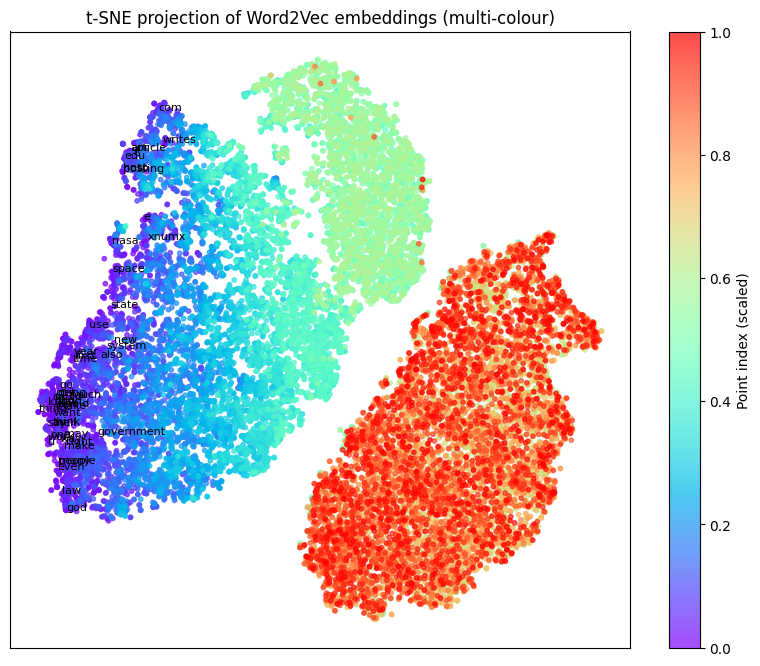

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1) Extract vectors and labels from your Word2Vec model
wv      = w2v_model.wv
words   = wv.index_to_key
vectors = wv.vectors

# 2) Run t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    init='pca'
)
coords = tsne.fit_transform(vectors)

# 3) Build DataFrame
df_tsne = pd.DataFrame({
    'word': words,
    'x':     coords[:, 0],
    'y':     coords[:, 1]
})

# 4) Generate a distinct color for each point
colors = np.linspace(0, 1, len(df_tsne))

# 5) Plot in multiple colours using a colormap
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df_tsne['x'], df_tsne['y'],
    c=colors,
    cmap='rainbow',
    s=10,
    alpha=0.7
)
plt.colorbar(scatter, label='Point index (scaled)')
plt.title('t-SNE projection of Word2Vec embeddings (multi-colour)')
plt.xticks([]); plt.yticks([])

# 6) Annotate a few points (optional)
for i, token in enumerate(words[:50]):
    plt.text(df_tsne.loc[i, 'x']+0.2, df_tsne.loc[i, 'y']+0.2, token, fontsize=8)

plt.show()



Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7824b0585bc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.11/dist-packages/scipy.libs/libscipy_openblas-68440149.

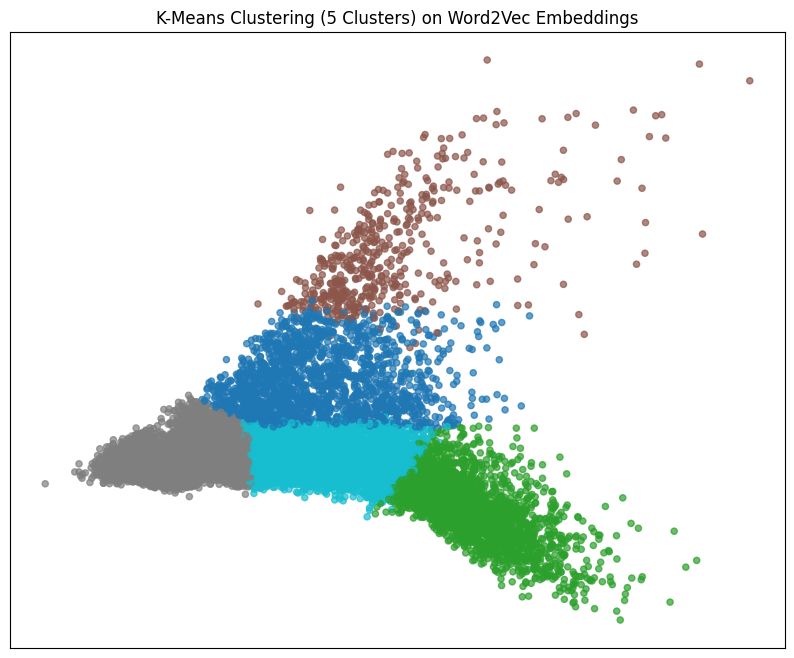

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1) Get your word vectors
wv      = w2v_model.wv
words   = wv.index_to_key
vectors = wv.vectors

# 2) Fit K-Means with 5 clusters
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(vectors)

# 3) Project to 2D for visualization
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

# 4) Plot each cluster in a different color
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    coords[:, 0],
    coords[:, 1],
    c=labels,
    cmap='tab10',
    s=20,
    alpha=0.7
)
plt.title('K-Means Clustering (5 Clusters) on Word2Vec Embeddings')
plt.xticks([])
plt.yticks([])
plt.show()


K-Means Silhouette Coefficient: 0.365
DBSCAN Silhouette Coefficient: 0.737


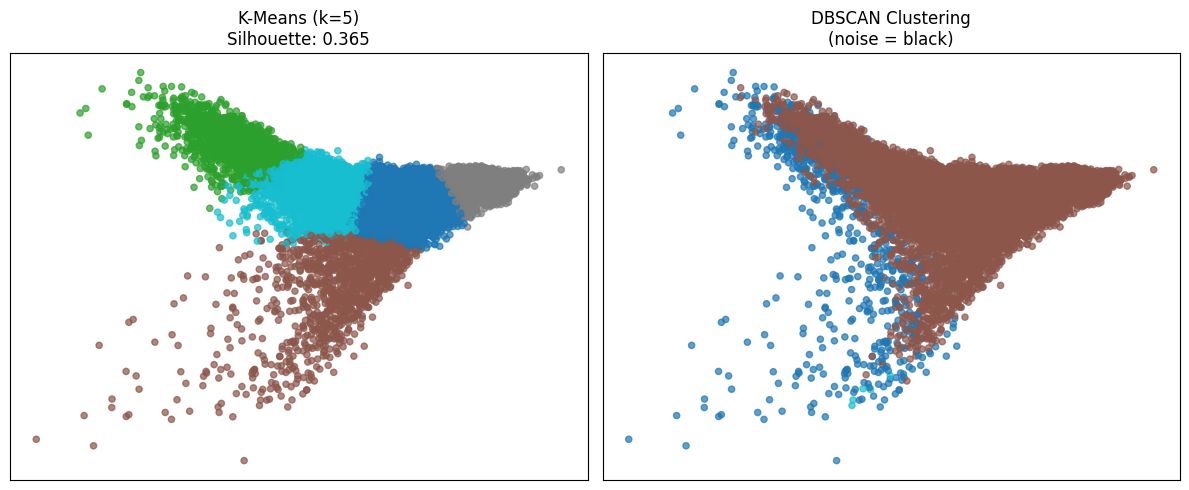

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1) Get your word vectors
wv      = w2v_model.wv
words   = wv.index_to_key
vectors = wv.vectors

# 2) Fit K-Means with 5 clusters
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(vectors)

# 3) Compute silhouette score for K-Means
kmeans_silhouette = silhouette_score(vectors, kmeans_labels)
print(f"K-Means Silhouette Coefficient: {kmeans_silhouette:.3f}")

# 4) Fit DBSCAN
#    You may need to tune eps and min_samples for your embeddings
dbscan = DBSCAN(eps=0.5, min_samples=5, metric='euclidean')
dbscan_labels = dbscan.fit_predict(vectors)

# 5) Compute silhouette score for DBSCAN (exclude noise points labeled -1)
mask = dbscan_labels != -1
unique_clusters = set(dbscan_labels[mask])
if len(unique_clusters) > 1:
    dbscan_silhouette = silhouette_score(vectors[mask], dbscan_labels[mask])
    print(f"DBSCAN Silhouette Coefficient: {dbscan_silhouette:.3f}")
else:
    print("DBSCAN did not form multiple clusters (excluding noise); silhouette score not available.")

# 6) Project to 2D for visualization
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

# 7) Plot K-Means and DBSCAN side by side
plt.figure(figsize=(12, 5))

# K-Means subplot
plt.subplot(1, 2, 1)
plt.scatter(coords[:, 0], coords[:, 1],
            c=kmeans_labels, cmap='tab10', s=20, alpha=0.7)
plt.title(f'K-Means (k={n_clusters})\nSilhouette: {kmeans_silhouette:.3f}')
plt.xticks([])
plt.yticks([])

# DBSCAN subplot
plt.subplot(1, 2, 2)
plt.scatter(coords[:, 0], coords[:, 1],
            c=dbscan_labels, cmap='tab10', s=20, alpha=0.7)
plt.title('DBSCAN Clustering\n(noise = black)')
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()


→ Found min_cluster_size=5 producing 5 clusters
HDBSCAN Silhouette Coefficient: 0.459


<ipython-input-12-a332c3f6695c>:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_labels))


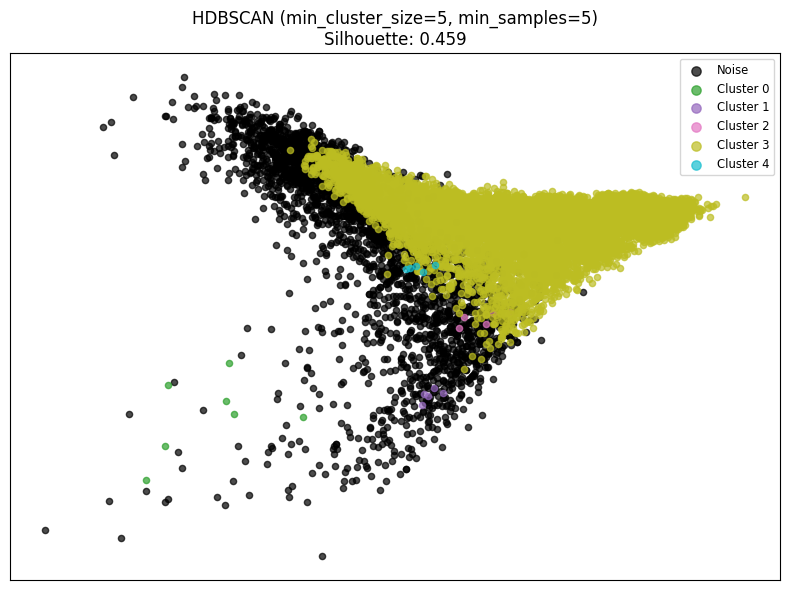

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
!pip install hdbscan


import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import hdbscan

# 1) Get your word vectors
wv      = w2v_model.wv
vectors = wv.vectors

# 2) Sweep min_cluster_size until we get exactly 5 clusters (excluding noise)
target_clusters       = 5
min_cluster_sizes     = list(range(5, 101, 5))   # try sizes from 5 up to 100 in steps of 5
chosen_min_cluster_sz = None

for size in min_cluster_sizes:
    clusterer_tmp = hdbscan.HDBSCAN(
        min_cluster_size=size,
        min_samples=5,
        metric='euclidean'
    )
    labels_tmp = clusterer_tmp.fit_predict(vectors)
    n_clusters = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    if n_clusters == target_clusters:
        chosen_min_cluster_sz = size
        print(f"→ Found min_cluster_size={size} producing {target_clusters} clusters")
        break

# Fallback
if chosen_min_cluster_sz is None:
    chosen_min_cluster_sz = 20
    print(f"No size in grid gave {target_clusters} clusters; using min_cluster_size={chosen_min_cluster_sz}")

# 3) Fit HDBSCAN with the chosen parameter
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=chosen_min_cluster_sz,
    min_samples=5,
    metric='euclidean'
)
labels = clusterer.fit_predict(vectors)

# 4) Compute Silhouette Coefficient (exclude noise)
mask = labels != -1
if len(set(labels[mask])) > 1:
    sil = silhouette_score(vectors[mask], labels[mask])
    print(f"HDBSCAN Silhouette Coefficient: {sil:.3f}")
else:
    print("HDBSCAN did not form multiple clusters; silhouette unavailable")

# 5) Project to 2D for visualization
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

# 6) Plot each cluster in a different color (noise in black)
plt.figure(figsize=(8, 6))
unique_labels = sorted(set(labels))
cmap = plt.cm.get_cmap('tab10', len(unique_labels))

for idx, lbl in enumerate(unique_labels):
    mask_lbl = (labels == lbl)
    color    = 'black' if lbl == -1 else cmap(idx)
    label    = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    plt.scatter(
        coords[mask_lbl, 0],
        coords[mask_lbl, 1],
        c=[color],
        label=label,
        s=20,
        alpha=0.7
    )

plt.title(f'HDBSCAN (min_cluster_size={chosen_min_cluster_sz}, min_samples=5)\nSilhouette: {sil:.3f}')
plt.xticks([]); plt.yticks([])
plt.legend(loc='best', fontsize='small', markerscale=1.5)
plt.tight_layout()
plt.show()



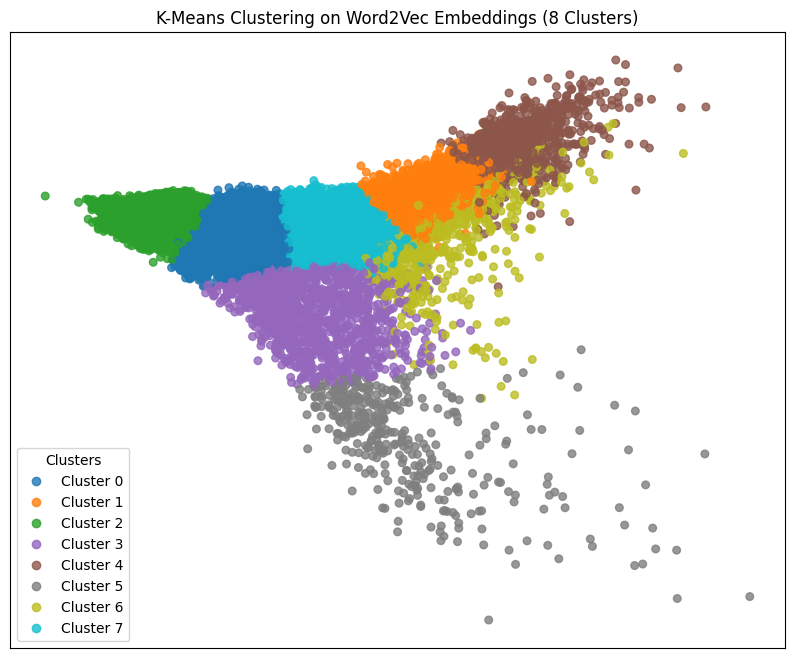

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1) Extract Word2Vec vectors and corresponding words
wv      = w2v_model.wv
words   = wv.index_to_key
vectors = wv.vectors

# 2) Fit K-Means on the embedding vectors
n_clusters = 8
kmeans     = KMeans(n_clusters=n_clusters, random_state=42)
labels     = kmeans.fit_predict(vectors)

# 3) Reduce to 2D for plotting
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

# 4) Plot each embedding colored by its cluster label
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=labels, cmap='tab10', s=30, alpha=0.8
)
plt.title(f'K-Means Clustering on Word2Vec Embeddings ({n_clusters} Clusters)')
plt.xticks([]); plt.yticks([])

# 5) Optional: add a legend mapping colors to cluster indices
handles, _ = scatter.legend_elements(prop="colors")
plt.legend(handles, [f"Cluster {i}" for i in range(n_clusters)],
           title="Clusters", loc="best")

plt.show()


In [ ]:
# Assuming you’ve already run the K-Means clustering and have:
#   `words`, `coords` (shape (vocab_size,2)), and `labels` (cluster IDs for each word)

# 1) Build (or update) the DataFrame with cluster labels
df_clusters = pd.DataFrame({
    'word':    words,
    'x':       coords[:, 0],
    'y':       coords[:, 1],
    'cluster': labels
})

# 2) Print the final DataFrame
print(df_clusters.head(10))

# If you want to save it for later:
df_clusters.to_csv('word2vec_kmeans_clusters.csv', index=False)
print("Saved cluster labels to word2vec_kmeans_clusters.csv")


      word         x         y  cluster
0    xnumx  0.716259 -0.979891        3
1      edu  0.798367 -2.606799        5
2      one  1.100260  0.481570        4
3      com  0.696847 -2.360349        5
4   writes  0.457346 -1.704036        5
5    would  1.254339  0.611985        4
6  article  0.647833 -2.294055        5
7   people  1.431692  0.986311        4
8     like  1.050998  0.281186        4
9     know  1.296246  0.356166        4
Saved cluster labels to word2vec_kmeans_clusters.csv


In [ ]:
import pandas as pd

# 1) Extract word vectors and cluster labels from your trained model and KMeans
words   = w2v_model.wv.index_to_key
vectors = w2v_model.wv.vectors
labels  = kmeans.labels_  # assumes you ran `kmeans = KMeans(...); labels = kmeans.fit_predict(vectors)`

# 2) Build a DataFrame of embeddings with their cluster assignments
emb_df = pd.DataFrame(
    vectors,
    index=words,
    columns=[f"dim_{i}" for i in range(vectors.shape[1])]
)
emb_df['cluster'] = labels

print("Embeddings DataFrame with cluster labels:")
print(emb_df.head())

# 3) (Optional) If you want to annotate your original df of documents—
#    create a mapping from word → cluster, then label each token list:
word_to_cluster = emb_df['cluster'].to_dict()

def label_tokens(token_list):
    return [word_to_cluster.get(tok, -1) for tok in token_list]

df['token_clusters'] = df['lemmatized_tokens'].apply(label_tokens)

print("\nOriginal DataFrame with token-level cluster labels:")
print(df[['lemmatized_tokens', 'token_clusters']].head())



Embeddings DataFrame with cluster labels:
           dim_0     dim_1     dim_2     dim_3     dim_4     dim_5     dim_6  \
xnumx   0.327736 -0.016298  0.205186  0.364752 -0.392610 -0.302250  0.462870   
edu    -0.331585  0.380954  0.355763  0.968524  0.492339 -1.012982  0.147592   
one    -0.043067  0.355578 -0.348448 -0.142987  0.061337 -0.030588 -0.076592   
com    -0.667934  1.075824  0.033635  0.158530 -0.388148 -0.796313  0.129006   
writes -0.445575  0.460978 -0.242983  0.509159  0.293324 -0.213929  0.247506   

           dim_7     dim_8     dim_9  ...    dim_91    dim_92    dim_93  \
xnumx   0.489628 -0.408022  0.185293  ... -0.001264  0.434335  0.724392   
edu     0.654777 -0.588080 -0.766982  ... -0.472607 -0.074542 -0.712136   
one     0.592688 -0.141079  0.253967  ...  0.012699  0.074319  0.108210   
com     1.222259  0.071329 -0.969112  ... -0.378956  0.198391 -0.204832   
writes  0.536747 -0.381507 -0.004312  ... -0.111221 -0.050432 -0.156234   

          dim_94    dim_95

In [ ]:
import pandas as pd
from sklearn.cluster       import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model  import LogisticRegression
from sklearn.svm           import SVC
from xgboost                import XGBClassifier
from sklearn.metrics       import accuracy_score, classification_report, confusion_matrix

# 1) Get your word vectors
wv      = w2v_model.wv
words   = wv.index_to_key
vectors = wv.vectors

# 2) Fit K-Means to assign a cluster label to each word
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(vectors)

# 3) Build emb_df: rows=words, cols=vector dims + 'cluster'
emb_df = pd.DataFrame(vectors, index=words)
emb_df['cluster'] = clusters

# 4) Reset index so "word" is a column, then train/test split
emb_df_reset = emb_df.reset_index().rename(columns={'index': 'word'})
train_df, test_df = train_test_split(
    emb_df_reset,
    test_size=0.2,
    random_state=42,
    stratify=emb_df_reset['cluster']
)

# 5) Prepare feature matrices and labels
feature_cols = [c for c in train_df.columns if c not in ('word', 'cluster')]
X_train, y_train = train_df[feature_cols], train_df['cluster']
X_test,  y_test  = test_df[feature_cols],  test_df['cluster']

# 6) Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

# 7) Support Vector Machine
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("\n=== Support Vector Machine ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

# 8) XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("\n=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))




=== Logistic Regression ===
Accuracy: 0.9850238257317904
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       338
           1       1.00      0.99      0.99       526
           2       0.99      0.94      0.96        98
           3       0.99      1.00      0.99      2428
           4       0.98      0.97      0.97      1017

    accuracy                           0.99      4407
   macro avg       0.98      0.97      0.98      4407
weighted avg       0.98      0.99      0.98      4407

Confusion Matrix:
 [[ 318    0    1    4   15]
 [   0  520    0    0    6]
 [   6    0   92    0    0]
 [   0    0    0 2428    0]
 [   4    1    0   29  983]]

=== Support Vector Machine ===
Accuracy: 0.9904697072838666
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       338
           1       0.99      0.99      0.99       526
           2       0.97      0.96      0.96        98
           3    

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:01:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== XGBoost ===
Accuracy: 0.989788972089857
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       338
           1       0.99      0.98      0.99       526
           2       0.98      0.94      0.96        98
           3       1.00      1.00      1.00      2428
           4       0.98      0.99      0.98      1017

    accuracy                           0.99      4407
   macro avg       0.98      0.98      0.98      4407
weighted avg       0.99      0.99      0.99      4407

Confusion Matrix:
 [[ 330    0    2    3    3]
 [   1  514    0    0   11]
 [   6    0   92    0    0]
 [   1    0    0 2424    3]
 [   6    3    0    6 1002]]
